In [ ]:
import sys
import os
import matplotlib.pyplot as plt
import gsw
# Numpy and xarray are always necessary
import numpy as np
import xarray as xr
import pandas as pd
from dask.diagnostics import ProgressBar

## Descriptions

This is an example to show how to smooth your binary MHW mask using a standard KNN cube. I smooth mask for each time step. Here I smooth over two adjacent timesteps. You could change for more timesteps. Make sure your binary MHW mask is on equal-spaced vertical and horizontal grids. If not, you need do interpolation first. Finally, you will get new binary MHW mask at each of your interested timepsteps.

### Define KNN function

In [15]:
import numpy as np
import xarray as xr
from scipy.ndimage import generic_filter

def KNN_smooth_in_3Dmap(old_mhw_mask, ocean_3dmask, KNN_horizontal_degree, KNN_vertical_level, level_depth, len_lat, len_lon):
    # Make MHW mask 'nan' for land grid
    mhw_mask_nan = xr.where(ocean_3dmask == 1, old_mhw_mask, np.nan)

    # Pad the 3D MHW mask with vertial and horizontal layers. Layer size depends on the KNN cube size.
    pad_vert = KNN_vertical_level // 2
    pad_horiz = KNN_horizontal_degree // 2
    padded = np.pad(mhw_mask_nan.values,
                            ((pad_vert, pad_vert),
                             (pad_horiz, pad_horiz),
                             (pad_horiz, pad_horiz)),
                            mode='constant', constant_values=np.nan)
    
    # As the global mask is wrapped around, so we need to manually adjust the MHW masks on zonal pads to be same along longitudes
    # Make the padded mask at 2 west-most longitudes as the mhw mask at 178.5E, 179.5E
    padded[1:level_depth+1,2:len_lat+2,:2] = mhw_mask_nan[:,:,-2:].values
    # Make the padded mask at 2 east-most longitudes as the mhw mask at 179.5W, 178.5W
    padded[1:level_depth+1,2:len_lat+2,-2:] = mhw_mask_nan[:,:,:2].values # 2 padded longitudes at east edge
    
    plt.imshow(padded[1])
    plt.gca().invert_yaxis()
    plt.axvline(x=2, color='red', linestyle='--', linewidth=1)
    plt.axvline(x= len_lon+1, color='red', linestyle='--', linewidth=1)
    
    # Define function to apply smoothing to each local window
    def smooth_fn(block):
        block = block.reshape((KNN_vertical_level, KNN_horizontal_degree, KNN_horizontal_degree))
        valid = ~np.isnan(block) # only consider neighbor ocean grid
        total_valid = np.sum(valid)
        if total_valid == 0:
            return np.nan
        mhw_count = np.sum(block == 1)
        return 1 if mhw_count >= total_valid / 2 else 0 # if over half of the neighbor grids have MHW ("1"), then the central grid has a MHW ("1"), otherwise, the central grid has no MHW ("0").
        
    # Apply the smooth_fn function using a 3D filter
    new_mask = np.full_like(mhw_mask_nan, np.nan)
    new_mask = generic_filter(
            padded,
            function=smooth_fn,
            size=(KNN_vertical_level, KNN_horizontal_degree, KNN_horizontal_degree),
            mode='constant',
            cval=np.nan
        )
    
    # Remove padding to get back to original shape
    result = new_mask[pad_vert:pad_vert+level_depth, pad_horiz:pad_horiz+len_lat, pad_horiz:pad_horiz+len_lon]
    # mask land grid to be nan
    result1 = xr.where(ocean_3dmask == 1,result, np.nan)
    return result1

### Load MHW mask and ocean mask

In [2]:
# load binary 3D ocean-land mask (0-land, 1-ocean)
ocean_3dmask = xr.load_dataarray('/your_oceanmask_file_path/global_ocean_3dmask_from_60S_to_60N.nc')

# Load binary 3D mhw mask data (0-non MHW, 1-MHW)
old_3d_mask = xr.open_dataarray('/your_mhwmask_file_path/global_mhw_3dmask_each5mgrid.nc')

0.3.0


In [5]:
ocean_3dmask

<xarray.DataArray 'ocean_grid' (depth: 400, lat: 120, lon: 360)>
array([[[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
...
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 0, 0, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 0, 0, ..., 1, 1, 1]],

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 0, 0, ..., 1, 1, 1]]])
Coordinates:
    time      datetime64[ns] 1993-01-01
  * lat       (lat) float64 -59.5 -58.5 -57.5 -56.5 ... 56.5 57.5 58.5 59.5
  * lon       (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth     (depth) int64 5 10 15 20 25 30 ... 1975 1980 1985 1990 1995 2000
    month     int64 1
    quantile  float64 0.9
Attributes:
    description:  ocean mask (1-ocean, 0-land)

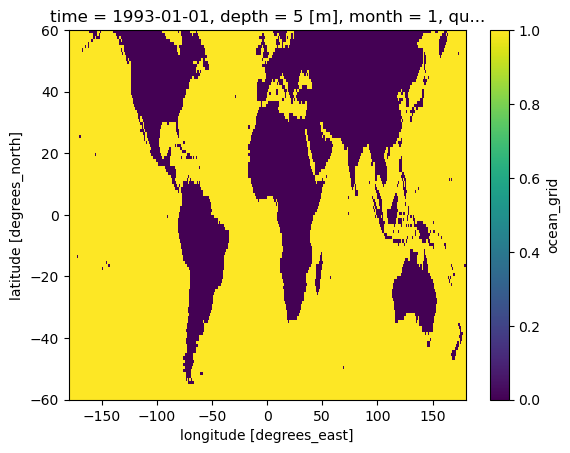

In [4]:
ocean_3dmask[0].plot()

In [6]:
old_3d_mask

<xarray.DataArray (time: 336, depth: 400, lat: 120, lon: 360)>
[5806080000 values with dtype=float64]
Coordinates:
  * time      (time) datetime64[ns] 1993-01-01 1993-02-01 ... 2020-12-01
  * lat       (lat) float64 -59.5 -58.5 -57.5 -56.5 ... 56.5 57.5 58.5 59.5
  * lon       (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
  * depth     (depth) int64 5 10 15 20 25 30 ... 1975 1980 1985 1990 1995 2000
    month     (time) int64 ...
    quantile  float64 ...

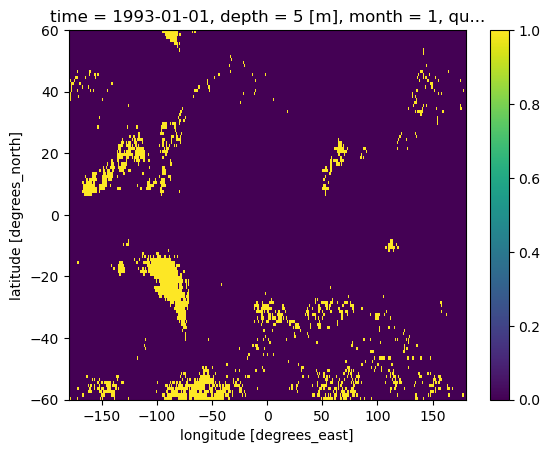

In [8]:
old_3d_mask.isel(time=0,depth=0).plot()

### Define your KNN cube size

In [11]:
# Specify the KNN cube size (size = X_knn **2 horizontal grid * Z_knn depth levels)
KNN_horizontal_degree = 5 # 5 longitude/latitude girds
KNN_vertical_level = 3 # 3 vertical levels

### Prepare new mhw mask

In [ ]:
# Calculate length of time, depth, latitute and longitude dimensions
len_month = len(old_3d_mask.time)
level_depth = len(old_3d_mask.depth)
len_lat = len(old_3d_mask.lat)
len_lon = len(old_3d_mask.lon)

In [ ]:
# Prepare new mhw mask for KNN updates, mask size = [timesteps, 3D dimensions (z,y,x)]
new_3d_mask = np.zeros([2,level_depth,len_lat,len_lon]) 

### Main function 

In [12]:
# Indice of initial timestep you want to loop
mymonths = 0

1993 January
Code ran in 230.4109 seconds
1993 February
Code ran in 234.7616 seconds


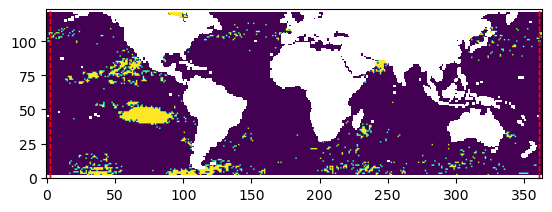

In [16]:
import time
# Loop through each month to update MHW mask
for i,tt in enumerate(range(mymonths,mymonths+2,1)):#len_month
    start_time = time.time()
    current_time = old_3d_mask.time[tt].dt.strftime('%Y %B').values
    print(current_time)
    # Extract the current MHW mask for the month
    mhw_3dmask = old_3d_mask[tt,:]
    # Update the MHW mask by applying KNN smoothing using a X_knn*X_knn*Z_knn (lat*lon*depth) box region
    new_3d_mask[i,:] = KNN_smooth_in_3Dmap(old_mhw_mask=mhw_3dmask,ocean_3dmask=ocean_3dmask, KNN_horizontal_degree = KNN_horizontal_degree,KNN_vertical_level = KNN_vertical_level,level_depth = level_depth,len_lat = len_lat,len_lon = len_lon)
    
    end_time = time.time()
    print(f"Code ran in {end_time - start_time:.4f} seconds")
    

In [51]:
# Make xarray array for new MHW mask, which has the same dimensions of old MHW mask. 
new_3d_mask_array = xr.DataArray(new_3d_mask,coords=dict(time=old_3d_mask.time[mymonths:mymonths+2], depths = old_3d_mask.depth, lat = old_3d_mask.lat, lon = old_3d_mask.lon),dims=old_3d_mask.dims)

In [53]:
# Save the new MHW mask in a netcdf file
#new_3d_mask_array.to_netcdf("./sMHWmask_"+str(mymonths)+'to'+str(mymonths+1)+"month_1993.2020.nc")

In [14]:
new_3d_mask_array

<xarray.DataArray (time: 2, depth: 400, lat: 120, lon: 360)>
[34560000 values with dtype=float64]
Coordinates:
  * time     (time) datetime64[ns] 1993-01-01 1993-02-01
    depths   (depth) int64 ...
  * lat      (lat) float64 -59.5 -58.5 -57.5 -56.5 -55.5 ... 56.5 57.5 58.5 59.5
  * lon      (lon) float64 -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Dimensions without coordinates: depth